In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import sys
sys.path.insert(0, "../..")

from src.model import MonotonicNN
from src.schemas import OptimizerParams
from src.utils import get_best_f1, calculate_brier_metrics, ice_pdp_plot_xgb_or_nn
from src.calibration.calibration_plots import calibration_diagnostics
from src.calibration.calibrator import Calibrator

## Load and EDA

In [2]:
# df = pd.read_csv("../data/customer_churn_dataset-training-master.csv")
df = pd.read_csv("../../data/Bank_Churn.csv")

In [3]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
# Drop non-features
df = df.drop(columns=["CustomerId", "Surname"])

# Drop categorical features
categorical_columns = ["Geography", "Gender"]
df = df.drop(columns=categorical_columns)

# Separate target
y = df["Exited"].values.astype(np.float32)
X = df.drop(columns=["Exited"])

In [5]:
ir_tr = float((y == 0).sum() / (y == 1).sum())
n0, n1 = (y == 0).sum(), (y == 1).sum()
mayoritary_label = 0.0 if n0 >= n1 else 1.0

print(f"Imbalance Ratio: {ir_tr:.2f} (n0={n0}, n1={n1})")

Imbalance Ratio: 3.91 (n0=7963, n1=2037)


In [6]:
# Train / validation / test split
x_tr, x_val_test, y_tr, y_val_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test
)

# Standardize features
scaler = StandardScaler()
x_tr_std = scaler.fit_transform(x_tr)
x_val_std = scaler.transform(x_val)
x_test_std = scaler.transform(x_test)

## Init and fit the model

In [7]:
# Convert to PyTorch tensors
x_tr_t = torch.tensor(x_tr_std, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

x_val_t = torch.tensor(x_val_std, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

x_test_t = torch.tensor(x_val_std, dtype=torch.float32)
y_test_t = torch.tensor(y_val, dtype=torch.float32)

In [8]:
# Define the NN
all_vars = list(x_tr.columns)  # must match column order
non_mon_vars = ['CreditScore', 'Tenure', 'HasCrCard', 'EstimatedSalary']
pos_mon_vars = ["Age", "Balance"]
neg_mon_vars = ["NumOfProducts", "IsActiveMember"]

model = MonotonicNN(
    all_variables=all_vars,
    non_monotonic_vars=non_mon_vars,
    positive_monotonic_vars=pos_mon_vars,
    negative_monotonic_vars=neg_mon_vars,
    hidden_non=16,
    hidden_pos=8,
    hidden_neg=8
)

In [9]:
# Fit the model
history = model.fit(
    x_tr=x_tr_t,
    y_tr=y_tr_t,
    x_val=x_val_t,
    y_val=y_val_t,
    pos_weight=1.0,
    epochs=100,
    optimizer_params=OptimizerParams(
        lr=1e-3,
        weight_decay=1e-5,
        batch_size=256,
        patience=5
    ),
    device="cpu",   # or "cuda" if available
    verbose=True
)

Epoch 1/100:   0%|          | 0/28 [00:00<?, ?batch/s, loss=1.2463]

Epoch 1 | Train: 1.54078 | Val: 1.40279


Epoch 2 | Train: 1.41266 | Val: 1.27869


Epoch 3/100:   0%|          | 0/28 [00:00<?, ?batch/s, loss=1.1780]

Epoch 3 | Train: 1.28848 | Val: 1.17063


...

Epoch 97 | Train: 0.43608 | Val: 0.41121


Epoch 98 | Train: 0.43334 | Val: 0.41153


Epoch 99/100:   0%|          | 0/28 [00:00<?, ?batch/s, loss=0.5429]

Epoch 99 | Train: 0.43711 | Val: 0.41098


Epoch 100 | Train: 0.43406 | Val: 0.41072


## Model evaluation

In [10]:
# Predict probs on validation set
probs_tr = model.predict_proba(x_tr_std)
probs_val = model.predict_proba(x_val_std)
probs_test = model.predict_proba(x_test_std)

# Compute best threshold & F1
best_t_tr, best_f1_tr, f1_tr_curve, thresholds = get_best_f1(y_tr, probs_tr)
best_t_val, best_f1_val, f1_val_curve, _ = get_best_f1(y_val, probs_val)
best_t_test, best_f1_test, f1_test_curve, _ = get_best_f1(y_test, probs_test)

print("- Train best F1:", round(best_f1_tr, 4), "at threshold", round(best_t_tr, 4))
print("- Val best F1:", round(best_f1_val, 4), "at threshold", round(best_t_val, 4))
print("- Test best F1:", round(best_f1_test, 4), "at threshold", round(best_t_test, 4))

- Train best F1: 0.4803 at threshold 0.2362
- Val best F1: 0.5051 at threshold 0.3769
- Test best F1: 0.5326 at threshold 0.2663


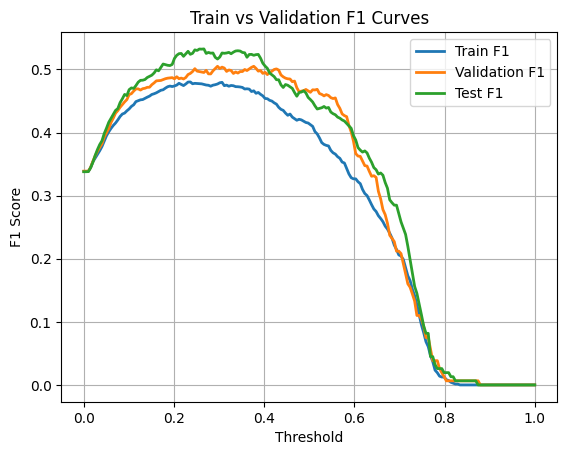

In [11]:
plt.plot(thresholds, f1_tr_curve, label="Train F1", linewidth=2)
plt.plot(thresholds, f1_val_curve, label="Validation F1", linewidth=2)
plt.plot(thresholds, f1_test_curve, label="Test F1", linewidth=2)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Train vs Validation F1 Curves")
plt.legend()
plt.grid(True)
plt.show()

## Probability calibration

In [12]:
# Predict logits
logits_tr = model.predict_logits(x_tr_std)
logits_val = model.predict_logits(x_val_std)
logits_test = model.predict_logits(x_test_std)

In [13]:
cal = Calibrator(method="temperature")
cal.fit(logits_val, y_val_t)

probs_tr_cal = cal.predict_proba(logits_tr)
probs_val_cal = cal.predict_proba(logits_val)
probs_test_cal = cal.predict_proba(logits_test)

In [14]:
# Compute brier score - non calibrated probs
bss_tr = calculate_brier_metrics(y_tr, probs_tr)
bss_val = calculate_brier_metrics(y_val, probs_val)
bss_test = calculate_brier_metrics(y_test, probs_test)
print("Non-calibrated probabilities")
print("- Train bss:", round(bss_tr["bss"], 4))
print("- Val bss:", round(bss_val["bss"], 4))
print("- Test bss:", round(bss_test["bss"], 4))

# Compute brier score - calibrated probs
bss_tr = calculate_brier_metrics(y_tr, probs_tr_cal)
bss_val = calculate_brier_metrics(y_val, probs_val_cal)
bss_test = calculate_brier_metrics(y_test, probs_test_cal)
print()
print("Calibrated probabilities")
print("- Train bss:", round(bss_tr["bss"], 4))
print("- Val bss:", round(bss_val["bss"], 4))
print("- Test bss:", round(bss_test["bss"], 4))

Non-calibrated probabilities
- Train bss: 0.1644
- Val bss: 0.2087
- Test bss: 0.2385

Calibrated probabilities
- Train bss: 0.1557
- Val bss: 0.2037
- Test bss: 0.2343


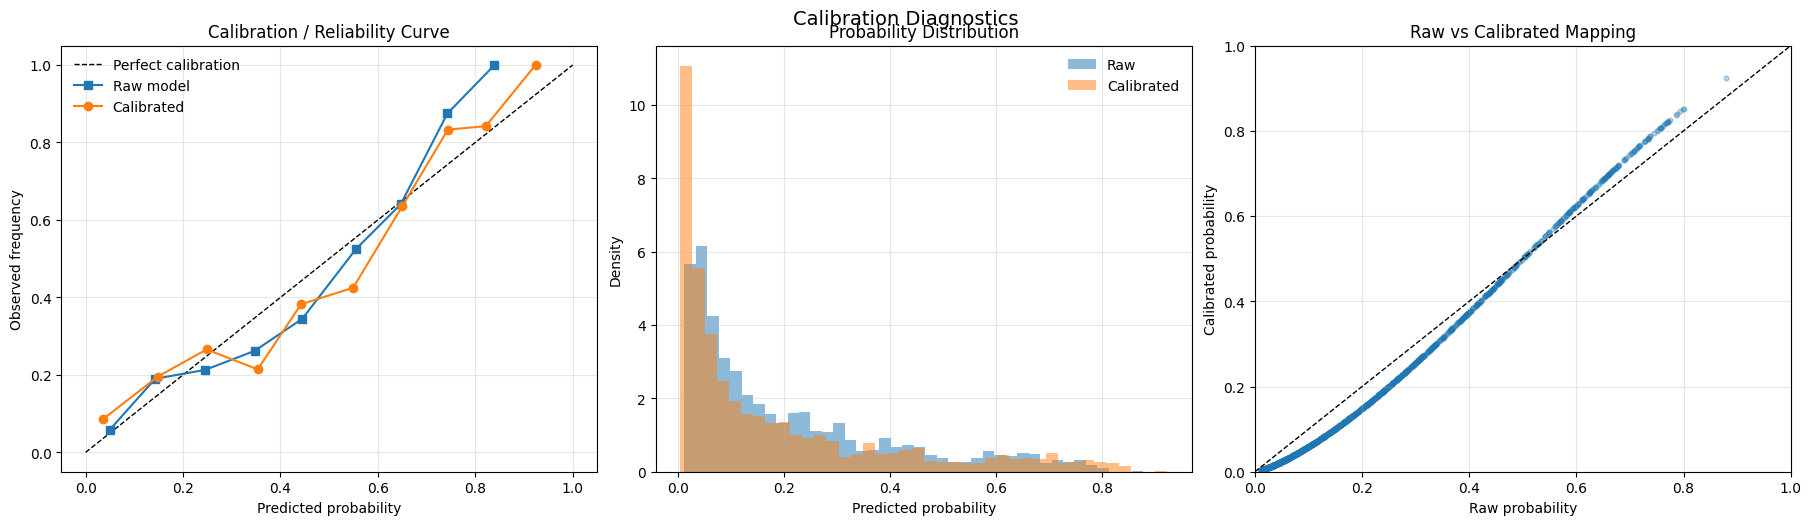

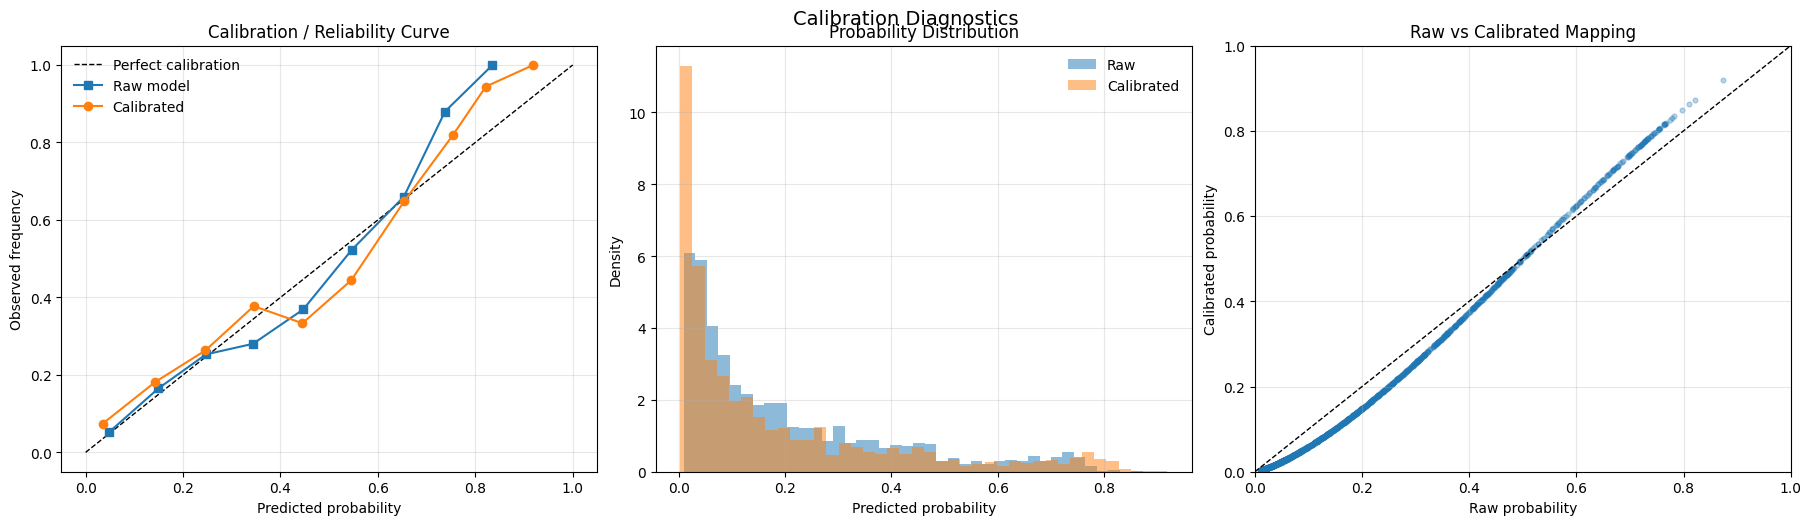

In [15]:
fig, axes = calibration_diagnostics(y_val, probs_val, probs_val_cal, n_bins=10, bins=40)
fig, axes = calibration_diagnostics(y_test, probs_test, probs_test_cal, n_bins=10, bins=40)
plt.show()

## Partial dependencies

In [16]:
FEATURE_NAME = "Age"
MODE = "pdp"

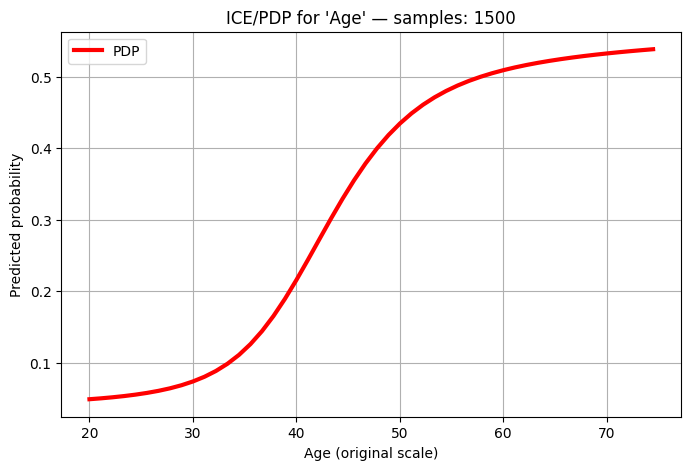

In [17]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_val.values,
    X_std=x_val_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=False,
)

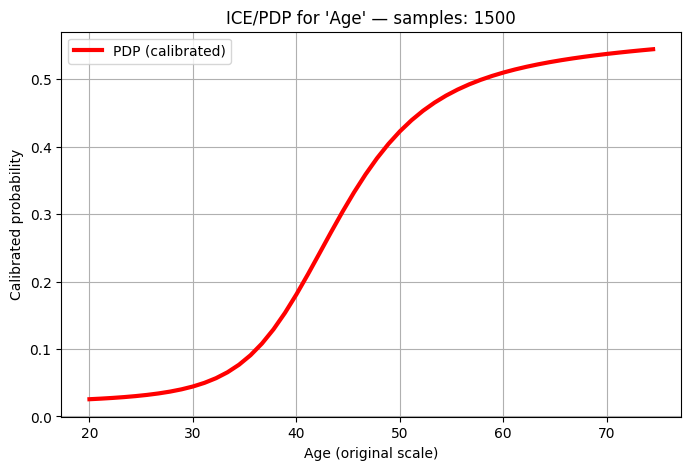

In [18]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_val.values,
    X_std=x_val_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=True,
)

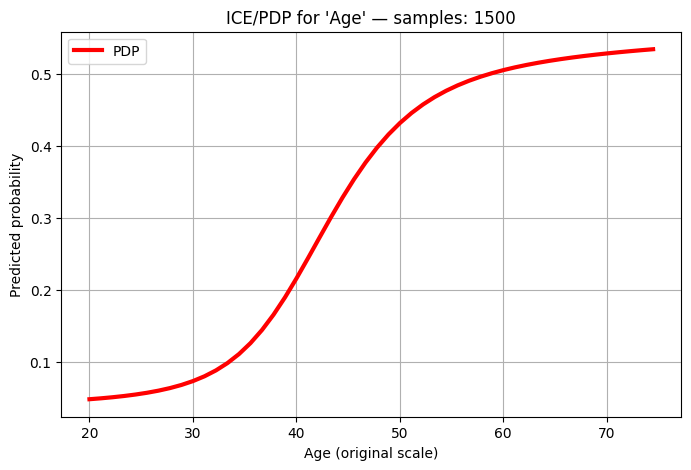

In [19]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_test.values,
    X_std=x_test_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=False,
)

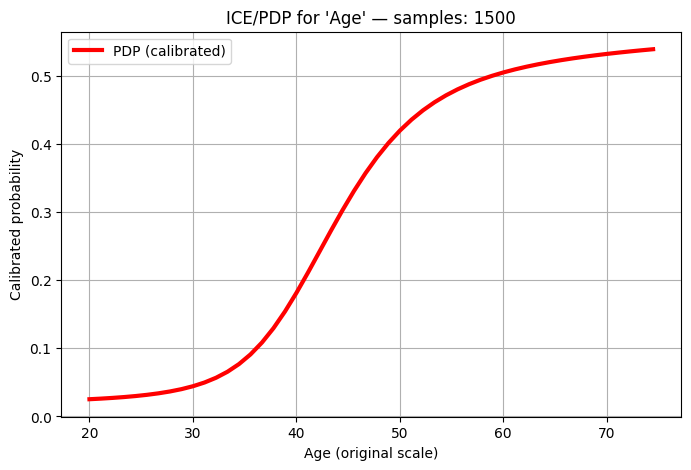

In [20]:
ice_age = ice_pdp_plot_xgb_or_nn(
    model=model,
    X_raw=x_test.values,
    X_std=x_test_std,
    feature_name=FEATURE_NAME,
    all_vars=all_vars,
    mode=MODE,
    num_points=50,
    n_samples=None,
    calibrator=cal,
    plot_calibrated=True,
)